In [11]:
import sys
from pathlib import Path

# Sube desde el directorio actual hasta encontrar la raíz del proyecto
# (la que contiene la carpeta 'src'). Funciona en cualquier SO/entorno.
project_root = Path.cwd().resolve()
while not (project_root / "src").is_dir() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 🗞️ Agente de búsqueda de notas de prensa (LangGraph + Google)

Agente mínimo que, **a partir de un símbolo bursátil**, busca en internet las notas
de prensa recientes de la empresa y devuelve un dosier estructurado.

El grafo es deliberadamente plano: **una entrada, un agente, una salida**.

```
START ──▶ agente_prensa ──▶ END
```

| | |
|---|---|
| **Entrada** | `{"ticker": "NVDA"}` |
| **Buscador** | Google Search vía *grounding* nativo de Gemini, con repliegue automático a Google News RSS |
| **Síntesis** | El mismo LLM de `src/config.get_llm()` (respeta `LLM_PROVIDER` del `.env`) |
| **Salida** | `notas_prensa` (lista estructurada), `sintesis`, `informe` (markdown) y `fuentes` |

> ⚠️ **Este notebook es exploratorio y vive fuera del grafo de producción.**
> En `src/graph/workflow.py` rige la invariante de que ningún LLM toca una variable
> de decisión. Aquí el LLM sí redacta el contenido, así que la salida es material
> informativo: no la conectes a un agente de decisión sin convertirla antes en
> señales deterministas.

In [12]:
"""Dependencias, configuración y modelo de lenguaje."""
import html
import re
import urllib.parse
import xml.etree.ElementTree as ET
from email.utils import parsedate_to_datetime
from typing import Any, Dict, List, Literal, Optional, TypedDict

import requests
import yfinance as yf
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.graph import END, START, StateGraph

from src.config import get_llm

load_dotenv(project_root / ".env")

# --- Parámetros de búsqueda -------------------------------------------------
MAX_RESULTADOS = 12          # notas candidatas que se pasan al LLM
VENTANA_DIAS = 120           # antigüedad máxima de las noticias
USAR_GROUNDING_GEMINI = True  # False = ir directo a Google News RSS
LOCALE_BUSQUEDA = {"hl": "en-US", "gl": "US", "ceid": "US:en"}
USER_AGENT = "Mozilla/5.0 (compatible; MultiAgentFinanciero/1.0)"

# --- LLM --------------------------------------------------------------------
# get_llm() devuelve el proveedor configurado en .env (aquí: Gemini) o None si
# no hay credenciales. El grounding de Google Search solo existe en Gemini.
llm = get_llm()
if llm is None:
    raise RuntimeError(
        "No hay LLM disponible. Revisa LLM_PROVIDER y la clave correspondiente en .env"
    )

ES_GEMINI = "GoogleGenerative" in type(llm).__name__
print(f"LLM activo: {type(llm).__name__} | grounding de Google disponible: {ES_GEMINI}")

LLM activo: ChatGoogleGenerativeAI | grounding de Google disponible: True


In [13]:
"""Contrato de datos: estado del grafo y esquema de salida del LLM."""


class NotaPrensa(BaseModel):
    """Una nota de prensa individual, tal y como la estructura el LLM."""

    titular: str = Field(description="Titular de la nota, en su idioma original")
    fecha: Optional[str] = Field(default=None, description="Fecha de publicación en formato YYYY-MM-DD")
    fuente: Optional[str] = Field(default=None, description="Medio o sala de prensa que la publica")
    url: Optional[str] = Field(default=None, description="URL exacta tomada de los resultados; nunca inventada")
    categoria: Literal[
        "RESULTADOS", "PRODUCTO", "ALIANZA", "CORPORATIVO", "REGULATORIO", "CAPITAL", "OTROS"
    ] = Field(description="Tipo de anuncio")
    relevancia: Literal["ALTA", "MEDIA", "BAJA"] = Field(description="Impacto potencial para el accionista")
    resumen: str = Field(description="Resumen en español de una o dos frases")


class DossierPrensa(BaseModel):
    """Salida completa del agente."""

    notas: List[NotaPrensa] = Field(default_factory=list, description="Notas ordenadas de más a menos reciente")
    sintesis: str = Field(description="Párrafo en español con la lectura conjunta de las notas")


class EstadoPrensa(TypedDict, total=False):
    """Estado del grafo. Solo `ticker` es obligatorio a la entrada."""

    # Entrada
    ticker: str
    # Contexto resuelto por el agente
    empresa: str
    consulta: str
    motor_busqueda: str
    # Salidas
    notas_prensa: List[Dict[str, Any]]
    sintesis: str
    fuentes: List[Dict[str, Any]]
    informe: str

In [14]:
"""Del símbolo bursátil al nombre de la empresa (yfinance, ya usado en el proyecto)."""

_ETIQUETAS_HTML = re.compile(r"<[^>]+>")


def limpiar_texto(texto: Optional[str]) -> str:
    """Quita etiquetas HTML y descodifica entidades de los campos del RSS."""
    return html.unescape(_ETIQUETAS_HTML.sub(" ", texto or "")).strip()


def resolver_nombre_empresa(ticker: str) -> str:
    """Devuelve el nombre largo de la empresa; si yfinance falla, el propio ticker.

    Buscar por nombre ("NVIDIA Corporation") da resultados mucho mejores que
    buscar por símbolo ("NVDA"), que colisiona con siglas de cualquier cosa.
    """
    try:
        info = yf.Ticker(ticker).info or {}
        return info.get("longName") or info.get("shortName") or ticker
    except Exception as exc:
        print(f"[yfinance] No se pudo resolver el nombre de {ticker}: {exc}")
        return ticker


def construir_consulta(empresa: str) -> str:
    """Consulta orientada a salas de prensa, no a artículos de opinión."""
    return (
        f'"{empresa}" ("press release" OR "nota de prensa" OR "announces" OR "anuncia") '
        f"when:{VENTANA_DIAS}d"
    )

In [15]:
"""Herramienta de búsqueda: Google Search (grounding de Gemini) con repliegue a Google News RSS."""


def _campo(obj: Any, clave: str) -> Any:
    """Lee una clave tanto si el objeto es un dict como si es un modelo del SDK."""
    if isinstance(obj, dict):
        return obj.get(clave)
    return getattr(obj, clave, None)


def _fecha_iso(fecha_rfc822: Optional[str]) -> Optional[str]:
    """'Mon, 17 Aug 2026 12:38:06 GMT' -> '2026-08-17'."""
    if not fecha_rfc822:
        return None
    try:
        return parsedate_to_datetime(fecha_rfc822).date().isoformat()
    except Exception:
        return None


def buscar_google_news_rss(consulta: str, max_resultados: int) -> List[Dict[str, Any]]:
    """Feed RSS público de Google News. No requiere clave de API."""
    url = "https://news.google.com/rss/search?" + urllib.parse.urlencode(
        {"q": consulta, **LOCALE_BUSQUEDA}
    )
    respuesta = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=20)
    respuesta.raise_for_status()

    resultados: List[Dict[str, Any]] = []
    for item in ET.fromstring(respuesta.content).findall(".//item")[:max_resultados]:
        resultados.append(
            {
                "titulo": limpiar_texto(item.findtext("title")),
                "url": (item.findtext("link") or "").strip(),
                "fuente": limpiar_texto(item.findtext("source")) or "Google News",
                "fecha": _fecha_iso(item.findtext("pubDate")),
                "extracto": limpiar_texto(item.findtext("description"))[:400],
            }
        )
    return resultados


def buscar_grounding_gemini(consulta: str, max_resultados: int) -> Dict[str, Any]:
    """Deja que Gemini busque en Google por su cuenta y devuelve sus fuentes citadas."""
    peticion = (
        f"Busca en Google las notas de prensa oficiales más recientes relacionadas con: {consulta}. "
        "Prioriza salas de prensa corporativas y relaciones con inversores. "
        "Resume brevemente qué has encontrado."
    )
    respuesta = llm.invoke(peticion, tools=[{"google_search": {}}])

    metadatos = respuesta.response_metadata or {}
    grounding = metadatos.get("grounding_metadata") or {}
    fuentes: List[Dict[str, Any]] = []
    for trozo in (_campo(grounding, "grounding_chunks") or [])[:max_resultados]:
        web = _campo(trozo, "web")
        if not web:
            continue
        fuentes.append(
            {
                "titulo": _campo(web, "title") or "(sin título)",
                "url": _campo(web, "uri") or "",
                "fuente": _campo(web, "domain") or _campo(web, "title") or "Google Search",
                "fecha": None,
                "extracto": "",
            }
        )
    return {"resultados": fuentes, "texto_modelo": respuesta.text}


def buscar_en_google(empresa: str, max_resultados: int = MAX_RESULTADOS) -> Dict[str, Any]:
    """Intenta el grounding de Google; si no hay cuota o falla, usa Google News RSS."""
    consulta = construir_consulta(empresa)

    if USAR_GROUNDING_GEMINI and ES_GEMINI:
        try:
            busqueda = buscar_grounding_gemini(consulta, max_resultados)
            if busqueda["resultados"]:
                return {"motor": "gemini_google_search", "consulta": consulta, **busqueda}
        except Exception as exc:
            print(f"[buscar] Grounding de Google no disponible ({type(exc).__name__}). Uso Google News RSS.")

    resultados = buscar_google_news_rss(consulta, max_resultados)
    if not resultados:  # consulta demasiado estricta: relajarla a solo el nombre
        resultados = buscar_google_news_rss(f'"{empresa}" when:{VENTANA_DIAS}d', max_resultados)

    return {
        "motor": "google_news_rss",
        "consulta": consulta,
        "resultados": resultados,
        "texto_modelo": None,
    }

In [16]:
"""El agente: único nodo del grafo. Busca, estructura con el LLM y redacta el informe."""

INSTRUCCIONES = (
    "Eres un analista de relaciones con inversores. Recibes resultados de búsqueda web "
    "sobre una empresa cotizada y debes destilar sus NOTAS DE PRENSA y anuncios corporativos.\n"
    "Reglas estrictas:\n"
    "1. Usa EXCLUSIVAMENTE los resultados proporcionados. No añadas hechos de tu memoria.\n"
    "2. Copia las URL literalmente de los resultados. Si una nota no tiene URL, deja el campo vacío.\n"
    "3. Descarta opinión, rumores, listas de recomendaciones bursátiles y contenido promocional "
    "de terceros: solo anuncios atribuibles a la empresa o a sus contrapartes.\n"
    "4. Los avisos de bufetes de abogados captando demandantes ('investor alert', "
    "'lead plaintiff', 'class action deadline') saturan estos feeds y no son "
    "comunicación de la empresa: "
    "consérvalos solo si aportan un hecho litigioso concreto, y como máximo uno.\n"
    "5. Ordena de más reciente a más antigua y no repitas la misma noticia dos veces.\n"
    "6. Si no hay ninguna nota de prensa legítima, devuelve la lista vacía y dilo en la síntesis.\n"
    "7. Escribe resúmenes y síntesis en español."
)


def _formatear_resultados(resultados: List[Dict[str, Any]]) -> str:
    """Serializa los resultados de búsqueda para el prompt."""
    lineas = []
    for i, r in enumerate(resultados, 1):
        lineas.append(
            f"[{i}] {r['titulo']}\n"
            f"    fecha: {r.get('fecha') or 'desconocida'} | fuente: {r.get('fuente') or '-'}\n"
            f"    url: {r.get('url') or '-'}\n"
            f"    extracto: {r.get('extracto') or '-'}"
        )
    return "\n".join(lineas)


def _renderizar_informe(ticker: str, empresa: str, dossier: DossierPrensa, motor: str) -> str:
    """Convierte el dosier en markdown legible."""
    partes = [
        f"# 🗞️ Notas de prensa — {empresa} ({ticker})",
        "",
        f"*Buscador: `{motor}` · ventana: últimos {VENTANA_DIAS} días · {len(dossier.notas)} nota(s)*",
        "",
        "## Síntesis",
        "",
        dossier.sintesis or "_Sin síntesis._",
        "",
        "## Detalle",
        "",
    ]
    if not dossier.notas:
        partes.append("_No se han encontrado notas de prensa en la ventana consultada._")
    for nota in dossier.notas:
        titular = f"[{nota.titular}]({nota.url})" if nota.url else nota.titular
        partes.append(f"### {titular}")
        partes.append(
            f"`{nota.fecha or 's/f'}` · **{nota.categoria}** · relevancia **{nota.relevancia}**"
            f" · _{nota.fuente or 'fuente desconocida'}_"
        )
        partes.append("")
        partes.append(nota.resumen)
        partes.append("")
    return "\n".join(partes)


def agente_prensa(estado: EstadoPrensa) -> Dict[str, Any]:
    """Nodo único: ticker -> nombre -> búsqueda en Google -> dosier estructurado."""
    ticker = estado["ticker"].strip().upper()
    empresa = estado.get("empresa") or resolver_nombre_empresa(ticker)

    busqueda = buscar_en_google(empresa)
    resultados = busqueda["resultados"]
    print(f"[{ticker}] {empresa} -> {len(resultados)} resultado(s) vía {busqueda['motor']}")

    if not resultados:
        dossier = DossierPrensa(
            notas=[],
            sintesis=f"La búsqueda no ha devuelto resultados para {empresa} ({ticker}).",
        )
    else:
        contexto = _formatear_resultados(resultados)
        if busqueda.get("texto_modelo"):
            contexto += f"\n\nResumen previo del buscador:\n{busqueda['texto_modelo']}"

        dossier = llm.with_structured_output(DossierPrensa).invoke(
            f"{INSTRUCCIONES}\n\n"
            f"Empresa: {empresa} (símbolo {ticker})\n"
            f"Resultados de búsqueda:\n{contexto}"
        )

    return {
        "empresa": empresa,
        "consulta": busqueda["consulta"],
        "motor_busqueda": busqueda["motor"],
        "notas_prensa": [n.model_dump() for n in dossier.notas],
        "sintesis": dossier.sintesis,
        "fuentes": resultados,
        "informe": _renderizar_informe(ticker, empresa, dossier, busqueda["motor"]),
    }

In [17]:
"""El grafo: una entrada, un agente, una salida."""

constructor = StateGraph(EstadoPrensa)
constructor.add_node("agente_prensa", agente_prensa)
constructor.add_edge(START, "agente_prensa")
constructor.add_edge("agente_prensa", END)

app_prensa = constructor.compile()
print(app_prensa.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agente_prensa(agente_prensa)
	__end__([<p>__end__</p>]):::last
	__start__ --> agente_prensa;
	agente_prensa --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



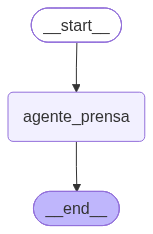

In [18]:
from IPython.display import Image, display

# draw_mermaid_png() devuelve bytes crudos de PNG; hay que envolverlos en
# Image() para que el notebook los renderice como imagen (no como texto).
display(Image(app_prensa.get_graph().draw_mermaid_png()))

In [19]:
"""Ejecución: el único argumento obligatorio es el símbolo bursátil."""
from IPython.display import Markdown

TICKER = "DOCN"

resultado = app_prensa.invoke({"ticker": TICKER})
display(Markdown(resultado["informe"]))

[buscar] Grounding de Google no disponible (ChatGoogleGenerativeAIError). Uso Google News RSS.
[DOCN] DigitalOcean Holdings, Inc. -> 12 resultado(s) vía google_news_rss


# 🗞️ Notas de prensa — DigitalOcean Holdings, Inc. (DOCN)

*Buscador: `google_news_rss` · ventana: últimos 120 días · 9 nota(s)*

## Síntesis

Durante el periodo analizado, DigitalOcean ha comunicado acontecimientos clave de índole financiera y estratégica. Destacan la publicación de sus resultados del segundo trimestre de 2026, junto con importantes operaciones de gestión de capital como la recompra de notas convertibles para reducir el apalancamiento y la ampliación de su participación institucional por parte de inversores como BlackRock y JPMorgan. Asimismo, la empresa ha reportado un fuerte impulso comercial en el segmento de inteligencia artificial —reflejado en el aumento de sus obligaciones de desempeño y el reciente lanzamiento de agentes de IA de Cloudways—, todo lo cual apunta a una fase activa de reestructuración financiera y expansión de su oferta tecnológica.

## Detalle

### [Cloudways Launches Managed AI Agents With General Availability of OpenClaw and Hermes](https://news.google.com/rss/articles/CBMijgFBVV95cUxQZDdtRzZvZ294RGstTXdrbkk3dE9NSVZVU052WndDSlI4NlQyeVBlQVRiR0piM2FBVU5xM2NPTkxnckdjV1MzNm5rMV9aeG4xWm1Yb2UtTjdicm5ZWXBtOU1kN1BGcUppbG9jVnppWmE5Um9STGF4eXdhdUxLOWE1aUhQOUs5VWdlU3VkNk13?oc=5)
`2026-08-17` · **PRODUCTO** · relevancia **ALTA** · _Yahoo! Finance Canada_

Cloudways, filial de DigitalOcean, ha anunciado el lanzamiento general de agentes de IA gestionados OpenClaw y Hermes.

### [DigitalOcean Announces Second Quarter 2026 Financial Results](https://news.google.com/rss/articles/CBMiuAFBVV95cUxPSVBXcE11TVNXRVhnZW5GUjJBdWlSSmM3dGlrYzVTWVQycjNQVXpOaUFvNDNROWxfR1RmZ2FnZlhGXzJnbXNDNmlJNUx5REFSUm9kYmFaQmVscFBJb3NYdVJTbktCdEN4OElyQ2xiNWVBZ2poWXVIcG94SjhQRVlPWEJvT1BfZUhZQXpBa3ZyQVNwV3hWQ3JvNHh2TUZDUlBKTFJrbVQwZW1uY1VZN0l3aVFwdXAyaW1E?oc=5)
`2026-08-04` · **RESULTADOS** · relevancia **ALTA** · _Business Wire_

DigitalOcean ha publicado sus resultados financieros correspondientes al segundo trimestre de 2026.

### [BlackRock (DOCN holder) discloses 7.6% beneficial stake in DigitalOcean](https://news.google.com/rss/articles/CBMiywFBVV95cUxPeVNDYk8yYVdXQ1lqVHpaV25IQzN3eG9KLVRfcldLdnFRY3B2TzZMTWRoY3JuOEt1RkFQODYxY251VFN2dDFfWlJOX0NEU0F0aTU1R0tCUGdwNUEtNUJrZ2tRb2xqVDk4QzBNcGNQTWtzcVpxM21xVkVfZ3hmdzhDSG96RW9NOXcwX3VCM25IMWFKd1RqUWNQRFdSelR5ZWw0ZDFyWFQyQ2E4M1NLRnY1QTM5QkZkY1R1UlVJNllQdklockFLc2plOElRbw?oc=5)
`2026-07-28` · **CAPITAL** · relevancia **MEDIA** · _Stock Titan_

BlackRock ha notificado una participación beneficiaria del 7,6% en DigitalOcean.

### [JPMorgan Chase & Co. (DOCN) discloses 13.0% beneficial stake in DigitalOcean](https://news.google.com/rss/articles/CBMiywFBVV95cUxNZm40QjRETmZ1ckp2U3QwNllteTVwUmNleGNJYXdsRXpoeTEwcmJBOGJ6cHliejZMSURwTjBuTEE5NjQ5XzJRUHpMNFpyY3JCcTI2WXFZckQ4QnF1dlVkNVl5bGJUVHpiRUluUHRPTUpDSUpBWHpVSjZQemIyR0FoNmc2d2ZldVFvb19aUi1PUGZUNWNIbmZtZF9PM3I5cEY3TER3b2VGdlBiR0tpVllPMVVaNVY0NVZ4MXo3V2NmQjB6ZWhiUEJ5TTd2QQ?oc=5)
`2026-07-27` · **CAPITAL** · relevancia **MEDIA** · _Stock Titan_

JPMorgan Chase & Co. ha declarado una participación beneficiaria del 13,0% en la compañía.

### [DigitalOcean Reduces Leverage with No Effective Dilution and Minimal Cash Usage, Creating Additional Capacity to Fuel Growth](https://news.google.com/rss/articles/CBMijAJBVV95cUxOelM2VXd2RTdkS2ttY1g1RXNYMEFLQ1RsY0pRcWR0eHFpNllIQUprS1JwVTJMaFl3SzYtRXBhM1ZySGFEV21rSm5RdE5HSHRvQUxtZXdzbHpLOFlmeEhPUEhERmNySHRaMDRNV0dLeWMwQnYyZWMxYThtNDhsWGxWMWxzN25UNklpYzgyUHJPMVN2TXQtaXpDNWtvVVFtZGNPYmw2clN2bFVVT0ptSzc0bjhES3N0aXVKRHZVM1pVbjN1MFNiaG92NHltRTVvdE1ha2RKa3NmZTB5bTRyRTB6OVMtVWhUUVJDOGJGdmVUS3c1eEZVREpfWWxHVFEtNjBfTE5TMUZ3Ty1QM3ZM?oc=5)
`2026-07-24` · **CORPORATIVO** · relevancia **ALTA** · _Business Wire_

DigitalOcean ha anunciado una reducción de su apalancamiento financiero mediante una operación estructurada para minimizar la dilución y el uso de caja.

### [DigitalOcean Announces Repurchase of Up to $500.0 Million Aggregate Principal Amount of 2030 Convertible Senior Notes. The Transaction Will Be Funded by a Concurrent Registered Direct Offering of Common Stock.](https://news.google.com/rss/articles/CBMipwFBVV95cUxNVk1ZN3k4SWRKS19jQmxfRGVrR0pXLWRTc1Z5SHRHaGstcXBOSkc3YzRSR2FYT0JzSFNrX2pqV1N2c0RnbXQwSm5ZR2FKb3bnRWpPQjd6QnpReUVOOHhLdnVtc2FIZXJwdVRXRlAxLUFUMnB3N0pxa0V2SUcwZE1TTjJDQzNJUUxOb0pObTJjNXdnX3hJellaalV1cUNkd1RNUkQzcVZKVQ?oc=5)
`2026-07-15` · **CAPITAL** · relevancia **ALTA** · _Yahoo Finance_

La compañía ha comunicado la recompra de hasta 500 millones de dólares en notas senior convertibles con vencimiento en 2030, financiadas mediante una ampliación de capital.

### [DigitalOcean says AI demand pushed RPO above $800M, up 10X](https://news.google.com/rss/articles/CBMivgFBVV95cUxNMlpEaEtxSEQ5X0ZCZVJoS1N4MlZUYkRpWVlJNXEwckpVQmJON2oxV2tENHBkZ0VXVnRfamYyNEM3X1dQNURqZUVBVENRQ3pLVGpCMkNDVXluUXU3TG5Xa1luZDFla3BEVWxhWDJtMXd0XzJiTDhHU29hMUlBcDFCLThaZDNWeVZtbW9mVS1hS2E0Z0hBeXBNWjBUeXhwcnFOcExZTkU4elcydUpkYXIzTm81bkVaT1dNdUtKQldR?oc=5)
`2026-07-07` · **CORPORATIVO** · relevancia **ALTA** · _Stock Titan_

DigitalOcean ha destacado que la fuerte demanda de inteligencia artificial ha impulsado sus obligaciones de desempeño restantes (RPO) por encima de los 800 millones de dólares.

### [DigitalOcean (NYSE: DOCN) director gets 112 RSUs instead of cash fees](https://news.google.com/rss/articles/CBMivAFBVV95cUxNMGdtWVRCLTJmRGx4b0RkUDlaZVJSQ29XbFhCMGVJanNtb3FVakVYMk9kVk9ON3NidFdJYzh3bGE5cEVWZkYxRDNQci00MlBJaGFSejdISEViaGMzTzg2QTdQcjJiZVFIVGh0TjI4bVVJQ0l3dEVrc0JBSTRqeW50NG5ZVk1IYnNzeHNWRy03cFRyVXlpdS1GUnJKSWh0dUZmb1BNc2d0bVd2N0V6TDBtbjlXY1VuRlpzeVRfVw?oc=5)
`2026-07-01` · **CORPORATIVO** · relevancia **BAJA** · _Stock Titan_

Un consejero de la empresa ha recibido 112 unidades de acciones restringidas (RSUs) en lugar de honorarios en efectivo.

### [DigitalOcean to Participate in Bank of America Global Technology Conference 2026](https://news.google.com/rss/articles/CBMi0wFBVV95cUxPOGEzZUVkNXdHc2NhakJpS0FCZnlpOXpxcThRc3NoOTVxX0k2VWIycGVjVE9JMThWVTRWNUxDY2dUcU5jQWlYOVdqSE1iOU1xUnRBRkFXOEkybU5BYklsVmtBN2lQZ2FMakxzRTlRS3MxbVNmTWhyVFZtOUYxWEtFNkF5R2xqNUF2ZG1ER0YyX3pXUjFFZDduZDEyakpndXNqTUVPNF92RzFkcV82TmNhcGw3TGVDZ3BLVnhKVXlFMkpLYVR5cnVpRUN3Zk5pR2RJZzhr?oc=5)
`2026-05-29` · **CORPORATIVO** · relevancia **BAJA** · _Business Wire_

DigitalOcean ha anunciado su participación en la conferencia tecnológica global de Bank of America.


In [20]:
"""La salida estructurada, lista para consumirse desde otro proceso."""
import json

print(json.dumps(resultado["notas_prensa"], indent=2, ensure_ascii=False)[:2000])

[
  {
    "titular": "Cloudways Launches Managed AI Agents With General Availability of OpenClaw and Hermes",
    "fecha": "2026-08-17",
    "fuente": "Yahoo! Finance Canada",
    "url": "https://news.google.com/rss/articles/CBMijgFBVV95cUxQZDdtRzZvZ294RGstTXdrbkk3dE9NSVZVU052WndDSlI4NlQyeVBlQVRiR0piM2FBVU5xM2NPTkxnckdjV1MzNm5rMV9aeG4xWm1Yb2UtTjdicm5ZWXBtOU1kN1BGcUppbG9jVnppWmE5Um9STGF4eXdhdUxLOWE1aUhQOUs5VWdlU3VkNk13?oc=5",
    "categoria": "PRODUCTO",
    "relevancia": "ALTA",
    "resumen": "Cloudways, filial de DigitalOcean, ha anunciado el lanzamiento general de agentes de IA gestionados OpenClaw y Hermes."
  },
  {
    "titular": "DigitalOcean Announces Second Quarter 2026 Financial Results",
    "fecha": "2026-08-04",
    "fuente": "Business Wire",
    "url": "https://news.google.com/rss/articles/CBMiuAFBVV95cUxPSVBXcE11TVNXRVhnZW5GUjJBdWlSSmM3dGlrYzVTWVQycjNQVXpOaUFvNDNROWxfR1RmZ2FnZlhGXzJnbXNDNmlJNUx5REFSUm9kYmFaQmVscFBJb3NYdVJTbktCdEN4OElyQ2xiNWVBZ2poWXVIcG94SjhQRVlPWEJvT1BfZ

In [21]:
"""Opcional: persistir el informe en src/notebooks/output/."""
from datetime import date

directorio = project_root / "src" / "notebooks" / "output"
directorio.mkdir(parents=True, exist_ok=True)

destino = directorio / f"prensa_{resultado['empresa'].split()[0].lower()}_{date.today().isoformat()}.md"
destino.write_text(resultado["informe"], encoding="utf-8")
print(f"Informe guardado en {destino}")

Informe guardado en C:\Users\cterr\Documents\10_Multi_Agent_Financiero\src\notebooks\output\prensa_digitalocean_2026-08-20.md


## Notas de uso

**Sobre el buscador.** `buscar_en_google()` intenta primero el *grounding* nativo de
Google Search dentro de Gemini y, si la llamada falla, cae automáticamente al feed RSS
de Google News. El repliegue no es decorativo: el nivel gratuito de la Gemini API
**no incluye cuota de grounding**, así que con la clave actual esa llamada devuelve
`429 RESOURCE_EXHAUSTED` mientras que la generación normal funciona sin problema.
En cuanto actives facturación en el proyecto de Google Cloud, el camino de grounding
empieza a funcionar solo. Para forzar el RSS y ahorrarte el intento fallido, pon
`USAR_GROUNDING_GEMINI = False`.

**Si prefieres Tavily.** Instala `langchain-tavily`, añade `TAVILY_API_KEY` al `.env`
y sustituye el cuerpo de `buscar_en_google()`; el resto del notebook no cambia porque
todos los buscadores devuelven la misma forma de diccionario:

```python
from langchain_tavily import TavilySearch

_tavily = TavilySearch(max_results=MAX_RESULTADOS, topic="news")

def buscar_tavily(consulta: str, max_resultados: int) -> list[dict]:
    respuesta = _tavily.invoke({"query": consulta})
    return [
        {
            "titulo": r["title"],
            "url": r["url"],
            "fuente": r.get("source") or r["url"],
            "fecha": r.get("published_date"),
            "extracto": (r.get("content") or "")[:400],
        }
        for r in respuesta["results"][:max_resultados]
    ]
```

**Límites conocidos.** Google News enlaza a través de una URL de redirección
(`news.google.com/rss/articles/...`), no a la URL final del medio. `when:120d` acota
la ventana pero Google la respeta de forma aproximada. Y el LLM decide qué es una nota
de prensa y qué no: es un filtro útil, no una fuente de verdad — para uso en decisiones
habría que contrastar contra la sala de prensa oficial o los 8-K de la SEC.